In [8]:
import torch 
from torch import nn
import matplotlib.pyplot as plt

## data preparing and loading 

In [2]:
weight =0.7
bias = 0.3

start=0
end =1
step=0.02

x = torch.arange(start,end,step).unsqueeze(dim=1)
x.reshape(5,10)
y = weight*x+bias
x[:10],y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
train_split = int(0.8*len(x))
train_split

40

In [4]:
x_train,y_train = x[: train_split],y[: train_split]


In [5]:
x_test,y_test = x[train_split : ],y[train_split : ]

In [6]:
len(x_train),len(x_test)

(40, 10)

In [9]:
def plot_pred(train_data = x_train,
              train_label = y_train,
              test_data = x_test,
              test_label = y_test,
              prediction=None):
    plt.figure(figsize=(10,7))
    plt.scatter(train_data,train_label,c="b",s=4,label="traning data")
    plt.scatter(test_data,test_label,c="g",s=4,label = "test data")
    if prediction is not None:
        plt.scatter(test_data,prediction,c="r",s=4,label = predictions)
    


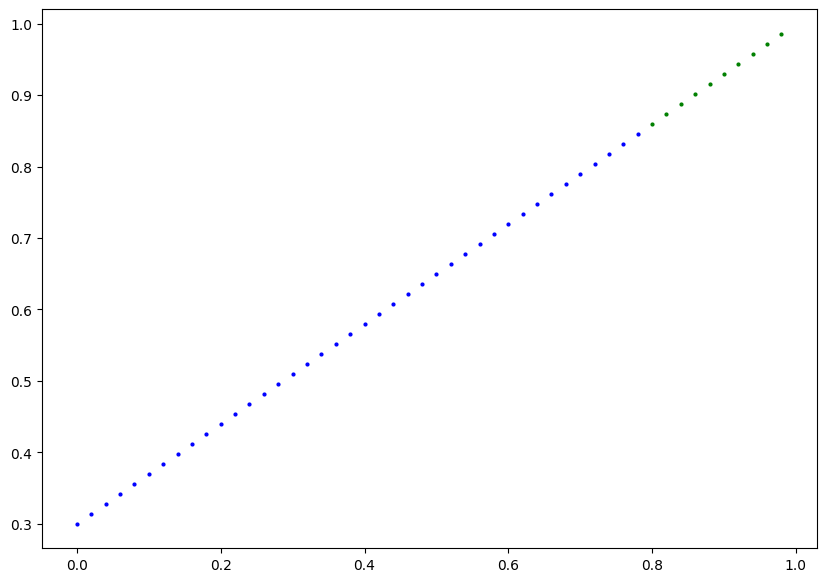

In [10]:
plot_pred()

In [ ]:
from torch import nn
class LinerRegression(nn.Module):   #almost everything is inherited from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float32))
        self.bias = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float32))
    def forward(self, x:torch.Tensor)->torch.Tensor:
        return self.weights * x + self.bias

* torch.nn: contrain all of the required modules 
* torch.nn.Parameter: what parameters should our model try and learn
* torch.nn.Module: base class for all neural network 
* torch.optim: optimiser to optimise the weights and biases 
* def forward(): all nn.module subclass require you to overwrite forward()
* torch.utils.data.Dataset
* torch.utils.data.Dataloader

In [15]:
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
model_0 = LinerRegression()
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [16]:
weight,bias

(0.7, 0.3)

## making prediction without traning 

In [ ]:
with torch.inference_mode():  #infrenece mode disables the gradient discent and all to just test the model instead of tracking everything 
    y_preds = model_0(x_test)  #can also use no_grad() instead of inference_mode

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [18]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

## loss function
helps us determine the error **lower is better**

## optimiser
check the loss and optimise the parameters

In [19]:
# setingup loss function 
loss_fn = nn.L1Loss()
# settingup optimiser 
optimiser = torch.optim.SGD(params = model_0.parameters(),lr=0.01) #lr is the learning rate of the model 

## building training loop

### steps involved:
* loop through data 
* forward pass: moving from input to output throgh the model
* calculate the loss: comp forward pass prediction to ground truth label 
* optimiser zero grad 
* loss backward 
* optimiser step



In [ ]:
epochs = 1   #an epoch is the number of the loops through the data

epoch_count = []
loss_values = []
test_loss_values = []

for epoch in range(epochs):
    model_0.train() #default mode in pytorch is training mode , sets all parameters to require gradients 
    # forward pass
    y_pred = model_0(x_train)
    #calculating the loss
    loss = loss_fn(y_pred,y_train)
    #optimiser
    optimiser.zero_grad()
    #back propogation 
    loss.backward()
    #step the optimiser
    optimiser.step()
    print(model_0.state_dict())
    # model_0.eval()
    if epoch%10 ==0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        


OrderedDict({'weights': tensor([0.6990]), 'bias': tensor([0.3093])})


In [33]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6951])), ('bias', tensor([0.2993]))])

In [39]:
with torch.inference_mode():
    ypred = model_0(x_test)
    print(loss_fn(ypred,y_test))
    print(f"accuracy: {(1-loss_fn(ypred,y_test))*100}")

tensor(0.0084)
accuracy: 99.15521240234375


In [44]:
with torch.inference_mode():
    print(model_0(torch.tensor([0.91])))

tensor([0.9454])


## saving the model and loading too

0. torch.save()
1. torch.load()
2. torch.nn.Module.load_state_dict(): saves the model in a dictionary format which is not useful for the larger models

In [46]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

In [47]:
MODEL_NAME = "best.pt"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
torch.save(obj=model_0.state_dict(),
            f = MODEL_SAVE_PATH)


In [48]:
torch.load(f=MODEL_SAVE_PATH)

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [49]:
loaded_model_0 = LinerRegression()

loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>